In [1]:
# test.py (Bridging with real Graph data)

from agents import *
from routing import distrito_tec,get_closest_place_node_id

sub_graph,routable_restaurants,residential_zones = distrito_tec()


In [2]:
routable_restaurants.head(5)

,element,id,geometry,amenity,name,wheelchair,cuisine,outdoor_seating,smoking,takeaway,...,air_conditioning,check_date,website:menu,contact:instagram,phone,level,building,building:levels,height,nn
0,node,890657529,POINT (-100.29377 25.65441),restaurant,Costeñito,limited,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.433046e+09
1,node,890657855,POINT (-100.29355 25.65472),restaurant,Wings Army,limited,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.433046e+09
2,node,890666591,POINT (-100.28436 25.64771),restaurant,Manhattan,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.049531e+09
3,node,1142899999,POINT (-100.29394 25.64558),restaurant,parrilla Argentina,NaN,steak_house,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.402993e+08
4,node,1142900483,POINT (-100.29419 25.64602),restaurant,Tacos el Morelense,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.600568e+08


In [4]:
residential_zones.head(5)

,element,id,geometry,landuse,name,place,addr:city,addr:street,building:levels,residential,operator,type
0,relation,9463437,"POLYGON ((-100.29348 25.66187, -100.2936 25.66...",residential,La Florida,NaN,NaN,NaN,NaN,NaN,NaN,multipolygon
1,way,163034600,"POLYGON ((-100.27483 25.62377, -100.27426 25.6...",residential,Contry,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,way,163034602,"POLYGON ((-100.27739 25.64568, -100.27511 25.6...",residential,Contry Tesoro,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,way,163034603,"POLYGON ((-100.28282 25.64297, -100.28238 25.6...",residential,Contry Lux,neighbourhood,NaN,NaN,NaN,NaN,NaN,NaN
4,way,163034605,"POLYGON ((-100.28052 25.64492, -100.27925 25.6...",residential,Las Musas,neighbourhood,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
routable_restaurants.iloc[[0]].to_crs

,element,id,geometry,amenity,name,wheelchair,cuisine,outdoor_seating,smoking,takeaway,...,air_conditioning,check_date,website:menu,contact:instagram,phone,level,building,building:levels,height,nn
0,node,890657529,POINT (-100.29377 25.65441),restaurant,Costeñito,limited,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.433046e+09


In [10]:
origin = get_closest_place_node_id(routable_restaurants.iloc[[0]],sub_graph)

In [11]:
origin

1433046436

In [15]:
sampled_zones = residential_zones.sample(100)
residential_nodes = [get_closest_place_node_id(residential_zones.sample(1),sub_graph) for i in range(100)]

In [17]:

# 2. Initialize Simulation with the real graph
sim = Simulation(step_size=1, graph=sub_graph)

# 3. Setup Entities using Real Node IDs

shared_node = 1433046436
resitential_node = 1682152103
# Add a restaurant
res = Restaurant(
    restaurant_id=1, 
    location=shared_node, 
    rating=5, 
    capacity=100, 
    avg_prep_time=300,
    service_radius=50000
)
sim.add_restaurant(res)

# Add 100 users on random residential nodes
for i in range(100):
    user = User(user_id=i, location=residential_nodes[i])
    sim.add_user(user)

# 4. Run the process
accepted = 0
for i in range(100):
    if sim.process_user_request(user_id=i, restaurant_id=1):
        accepted += 1

print(f"Simulation tick 0: {accepted} orders accepted at Restaurant 1")

# 5. Advance Time
sim.run_until(600)
ready = [o for o in sim.orders if o.status == "READY"]
print(f"After 10 mins: {len(ready)} orders are ready for pickup.")

Simulation tick 0: 94 orders accepted at Restaurant 1
After 10 mins: 84 orders are ready for pickup.


/Users/mikemachr/Desktop/citySim/venv/lib/python3.13/site-packages/osmnx/plot.py:352: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(od_x, od_y, s=orig_dest_size, c=route_color, alpha=route_alpha, edgecolor="none")


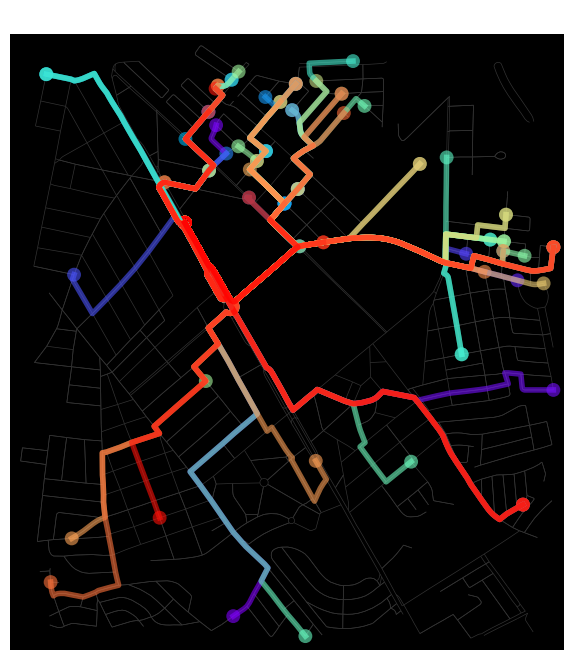

In [25]:
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 1. Filter valid routes
routes = [order.route_to_user for order in sim.orders if order.route_to_user is not None]

if routes:
    # 2. Generate a unique color for each route
    # We use a colormap to get a list of RGBA colors
    colors = cm.rainbow(np.linspace(0, 1, len(routes)))
    
    # 3. Plot the graph with multiple colors
    fig, ax = ox.plot_graph_routes(
        sub_graph, 
        routes, 
        route_colors=colors,   # Pass the list of generated colors
        route_linewidth=2,     # Thickness of the lines
        route_alpha=0.6,       # Transparency to see overlaps better
        node_size=0,           # Hide nodes
        bgcolor='k',           # Black background
        edge_color='#333333',  # Dim background streets
        edge_linewidth=0.5,
        show=False, 
        close=False
    )
    
    plt.title(f"Multi-color Delivery Routes ({len(routes)} orders)", color='white', fontsize=15)
    plt.show()
else:
    print("No routes found to plot.")